<a href="https://colab.research.google.com/github/lydiadipaola/grand-isle-water-level-ml/blob/main/NOAA_2021_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grand Isle, Louisiana: Short-Term Water-Level Prediction

Objective: Predict one-hour-ahead coastal water levels at NOAA station 8761724 (Grand Isle, Louisiana) using historical water-level observations.

Data: NOAA hourly water-level observations, 2021.

Predictors: Water levels lagged by 1, 2, 3, 6, 12, and 24 hours.

Target: Water level one hour ahead.

Validation: Chronological 80/20 train-test split.

Evaluation: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

Overview: This project evaluates whether machine-learning and statistical models can use recent water-level observations to predict short-term coastal water-level variability.

In [ ]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

In [ ]:
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?begin_date=20210101&end_date=20211231&station=8761724&product=hourly_height&datum=STND&time_zone=gmt&units=metric&format=csv"

df = pd.read_csv(url)

# Clean column names
df.columns = df.columns.str.strip()

# Display first five rows
df.head()

,Date Time,Water Level,Sigma,I,L
0,2021-01-01 00:00,2.424,0.000,0,0
1,2021-01-01 01:00,2.483,0.009,0,0
2,2021-01-01 02:00,2.514,0.007,0,0
3,2021-01-01 03:00,2.550,0.005,0,0
4,2021-01-01 04:00,2.563,0.006,0,0


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDescriptive statistics:")
display(df.describe())

Dataset shape: (8760, 5)

Columns:
['Date Time', 'Water Level', 'Sigma', 'I', 'L']

Missing values:
Date Time      0
Water Level    0
Sigma          0
I              0
L              0
dtype: int64

Descriptive statistics:


,Water Level,Sigma,I,L
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.166879,0.004921,0.000114,0.000228
std,0.190520,0.003226,0.010684,0.015109
min,1.569000,0.000000,0.000000,0.000000
25%,2.040000,0.003000,0.000000,0.000000
50%,2.172000,0.004000,0.000000,0.000000
75%,2.292000,0.006000,0.000000,0.000000
max,3.681000,0.045000,1.000000,1.000000


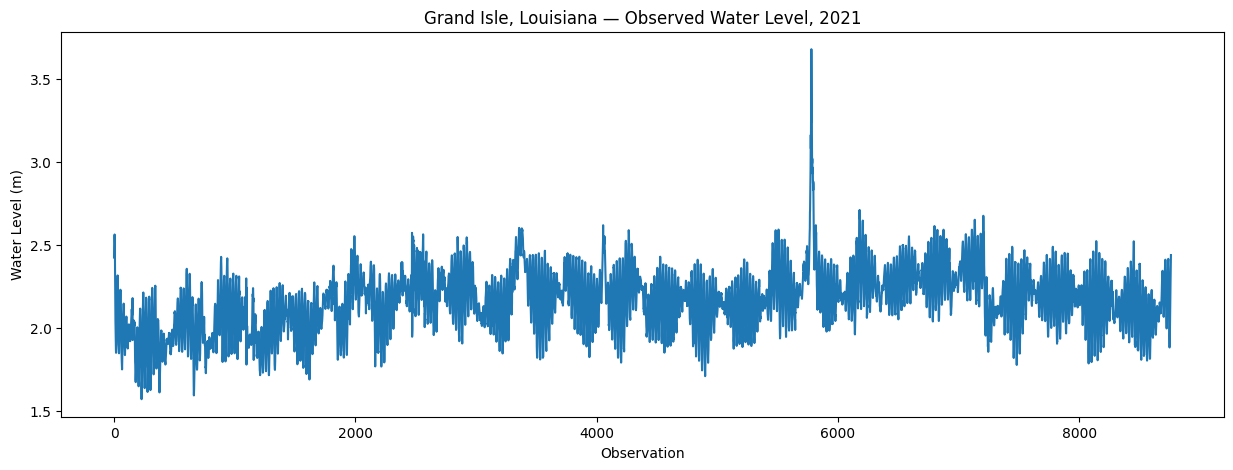

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(df["Water Level"])

plt.title("Grand Isle, Louisiana — Observed Water Level, 2021")
plt.xlabel("Observation")
plt.ylabel("Water Level (m)")

plt.show()

In [ ]:
# Convert Date Time to datetime
df["Date Time"] = pd.to_datetime(df["Date Time"])

# Sort chronologically
df = df.sort_values("Date Time").reset_index(drop=True)

# Create previous water-level predictors
df["level_1h"] = df["Water Level"].shift(1)
df["level_2h"] = df["Water Level"].shift(2)
df["level_3h"] = df["Water Level"].shift(3)
df["level_6h"] = df["Water Level"].shift(6)
df["level_12h"] = df["Water Level"].shift(12)
df["level_24h"] = df["Water Level"].shift(24)

# Target = water level one hour in the future
df["target"] = df["Water Level"].shift(-1)

# Remove rows with missing lag/target values
ml_df = df.dropna().reset_index(drop=True)

print("ML observations:", len(ml_df))

ML observations: 8735


In [ ]:
features = [
    "level_1h",
    "level_2h",
    "level_3h",
    "level_6h",
    "level_12h",
    "level_24h"
]

X = ml_df[features]
y = ml_df["target"]

print("Predictors:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Predictors:
['level_1h', 'level_2h', 'level_3h', 'level_6h', 'level_12h', 'level_24h']

X shape: (8735, 6)
y shape: (8735,)


In [ ]:
split = int(len(ml_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(ml_df["Date Time"].iloc[0], "to", ml_df["Date Time"].iloc[split - 1])

print("\nTesting period:")
print(ml_df["Date Time"].iloc[split], "to", ml_df["Date Time"].iloc[-1])

Training observations: 6988
Testing observations: 1747

Training period:
2021-01-02 00:00:00 to 2021-10-20 03:00:00

Testing period:
2021-10-20 04:00:00 to 2021-12-31 22:00:00


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost MAE:  {xgb_mae:.3f} m")
print(f"XGBoost RMSE: {xgb_rmse:.3f} m")
print(f"XGBoost R²:   {xgb_r2:.3f}")

XGBoost MAE:  0.022 m
XGBoost RMSE: 0.030 m
XGBoost R²:   0.968


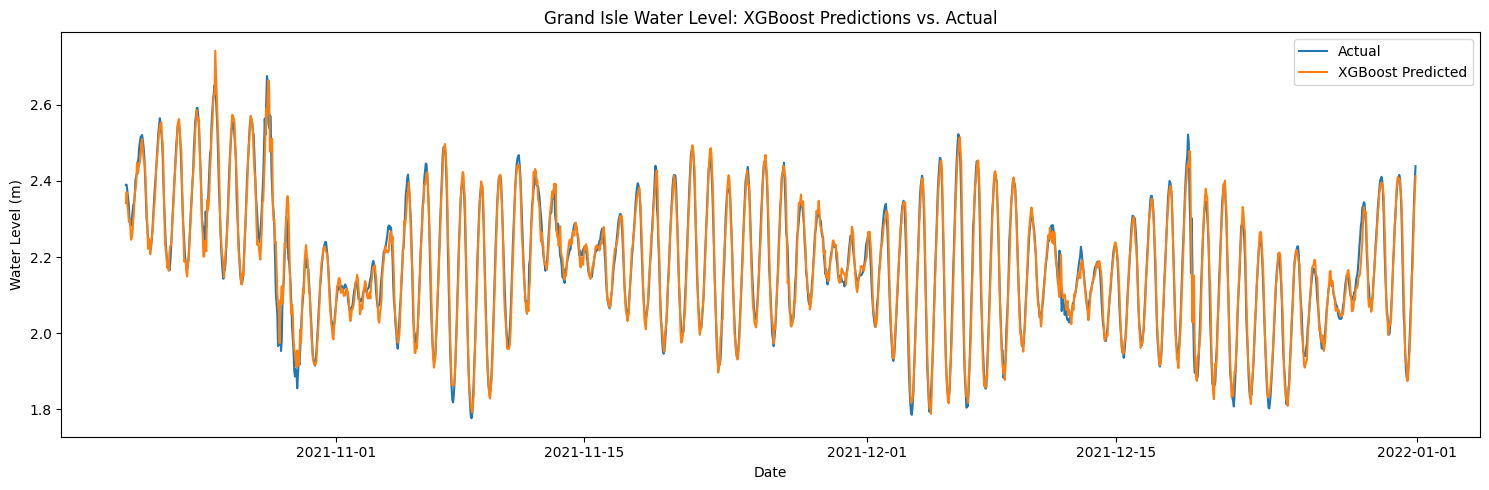

In [ ]:
# Create XGBoost results dataframe
xgb_results = pd.DataFrame({
    "Date Time": ml_df["Date Time"].iloc[split:],
    "Actual": y_test.values,
    "Predicted": xgb_pred
})

# Plot actual vs. predicted
plt.figure(figsize=(15, 5))

plt.plot(
    xgb_results["Date Time"],
    xgb_results["Actual"],
    label="Actual"
)

plt.plot(
    xgb_results["Date Time"],
    xgb_results["Predicted"],
    label="XGBoost Predicted"
)

plt.title("Grand Isle Water Level: XGBoost Predictions vs. Actual")
plt.xlabel("Date")
plt.ylabel("Water Level (m)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
0,level_1h,0.482690
5,level_24h,0.351241
1,level_2h,0.074661
2,level_3h,0.040175
3,level_6h,0.034698
4,level_12h,0.016535


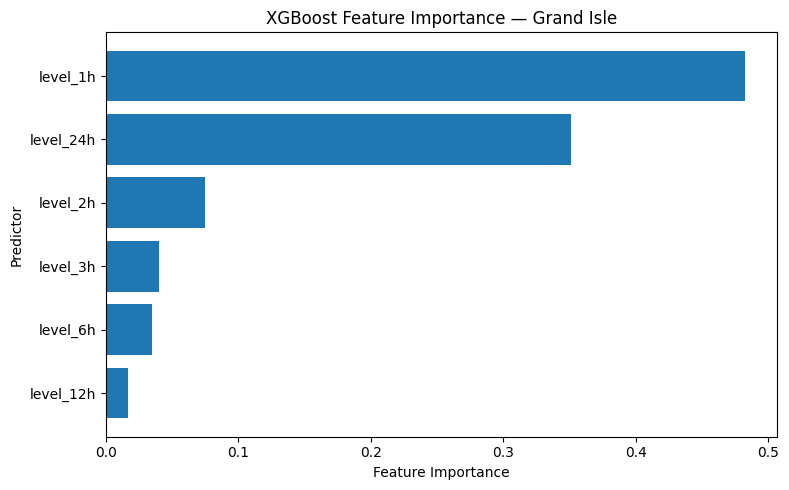

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("XGBoost Feature Importance — Grand Isle")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

XGBoost feature importance indicated that the one-hour and 24-hour lagged water levels were the most influential predictors, accounting for approximately 48% and 35% of total model feature importance, respectively. This suggests that both the immediate water-level state and information from the preceding daily cycle were particularly useful for short-term prediction.

In [ ]:
xgb_results["Residual"] = (
    xgb_results["Actual"] - xgb_results["Predicted"]
)

xgb_results["Absolute Error"] = abs(
    xgb_results["Residual"]
)

xgb_results.head()

,Date Time,Actual,Predicted,Residual,Absolute Error
6988,2021-10-20 04:00:00,2.390,2.342005,0.047995,0.047995
6989,2021-10-20 05:00:00,2.390,2.370646,0.019354,0.019354
6990,2021-10-20 06:00:00,2.373,2.337158,0.035842,0.035842
6991,2021-10-20 07:00:00,2.355,2.321598,0.033402,0.033402
6992,2021-10-20 08:00:00,2.335,2.293238,0.041762,0.041762


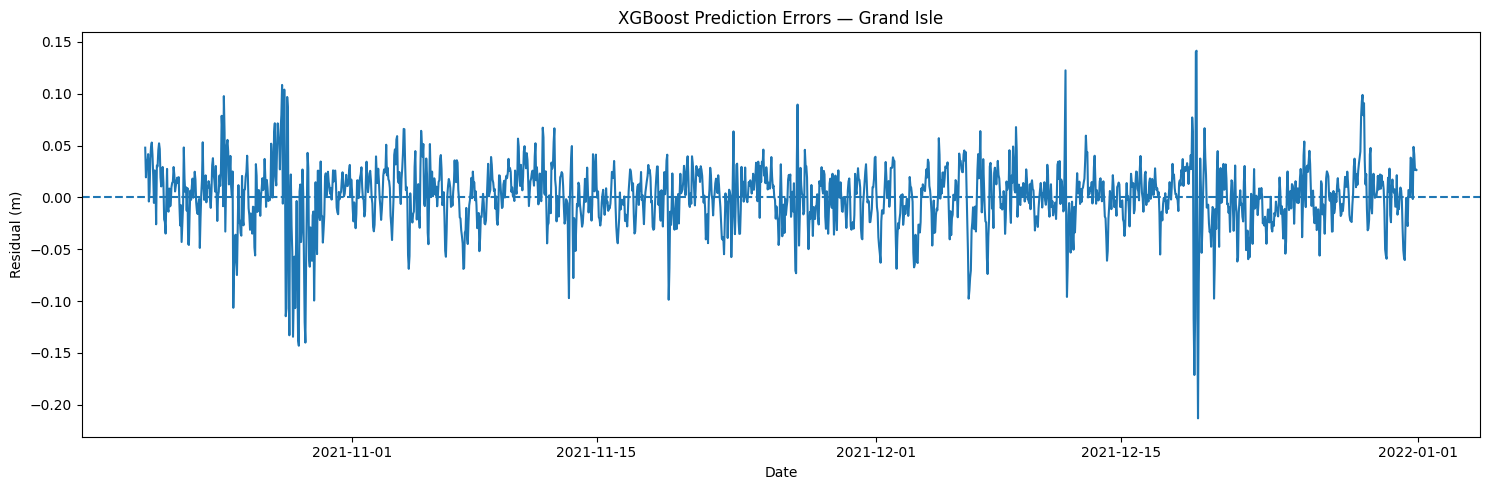

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    xgb_results["Date Time"],
    xgb_results["Residual"]
)

plt.axhline(0, linestyle="--")

plt.title("XGBoost Prediction Errors — Grand Isle")
plt.xlabel("Date")
plt.ylabel("Residual (m)")

plt.tight_layout()
plt.show()

XGBoost residuals were generally centered around zero, indicating limited systematic over- or under-prediction across the testing period. Most prediction errors were relatively small, although several larger residuals occurred during periods of rapid or less typical water-level changes. These larger errors suggest that historical water-level observations alone may not fully capture short-term variability during unusual conditions.

In [ ]:
print("Mean residual:", xgb_results["Residual"].mean())
print("Mean absolute error:", xgb_results["Absolute Error"].mean())
print("Maximum absolute error:", xgb_results["Absolute Error"].max())
print("95th percentile absolute error:",
      xgb_results["Absolute Error"].quantile(0.95))

Mean residual: 0.0005784044145650722
Mean absolute error: 0.021907182867621177
Maximum absolute error: 0.21315237236022955
95th percentile absolute error: 0.05945281085968018


XGBoost predictions showed minimal systematic bias, with a mean residual of 0.0006 m. The mean absolute error was 0.0219 m, while 95% of absolute prediction errors were below 0.0595 m. The maximum absolute error was 0.2132 m, indicating that the model performed well under typical conditions but had substantially larger errors during a small number of observations characterized by more rapid or unusual water-level changes.

In [ ]:
largest_errors = xgb_results.sort_values(
    "Absolute Error",
    ascending=False
)

display(
    largest_errors[
        ["Date Time", "Actual", "Predicted", "Residual", "Absolute Error"]
    ].head(10)
)

,Date Time,Actual,Predicted,Residual,Absolute Error
8434,2021-12-19 10:00:00,1.938,2.151152,-0.213152,0.213152
8429,2021-12-19 05:00:00,2.289,2.460335,-0.171335,0.171335
7199,2021-10-28 23:00:00,1.980,2.123092,-0.143092,0.143092
8432,2021-12-19 08:00:00,2.170,2.028458,0.141542,0.141542
8431,2021-12-19 07:00:00,2.302,2.161509,0.140491,0.140491
7208,2021-10-29 08:00:00,2.196,2.336065,-0.140065,0.140065
7198,2021-10-28 22:00:00,1.953,2.090479,-0.137479,0.137479
7191,2021-10-28 15:00:00,2.106,2.240440,-0.134440,0.134440
7186,2021-10-28 10:00:00,2.378,2.511007,-0.133007,0.133007
8252,2021-12-11 20:00:00,2.217,2.094405,0.122595,0.122595


The largest prediction errors were concentrated within several short periods rather than being evenly distributed throughout the testing period. The largest error occurred on December 19, 2021, with an absolute error of 0.213 m. Additional large errors occurred on October 28–29 and December 19. This clustering suggests that the model's predictive performance decreased during periods of rapid or atypical water-level variation.